# Building a Review-Based Book Recommender

Need to upload data/10000_reviews.csv and data/book_titles.csv to run

In this notebook we will:

1. **Load** Book metadata
2. **Clean** free-text fields
3. **Explore** data quality and distribution  
4. **Classify** books as *fiction* vs *non-fiction* using TF-IDF + Logistic Regression  
5. **Generate embeddings** from book descriptions using a Sentence Transformer  
6. **Build a vector search engine** to find books similar to a user’s query based on semantic meaning  
7. **Safely apply sentiment analysis** (using a pre-trained LLM) to label each book’s tone as *positive*, *negative*, or *neutral*
8. **Filter recommendations** by genre and tone preferences  
9. **Deploy an interactive Gradio dashboard** where users can enter a plot idea, choose filters, and get recommended books  

In [ ]:
import pandas as pd
import re
import ast
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
from transformers import pipeline
import gradio as gr
import joblib

### Load the Datasets (Colab)

In [2]:
# from google.colab import files
# import io

# # Upload files
# uploaded = files.upload()  # User selects two CSVs

# # Convert uploaded files into DataFrames
# dfs = []
# for fname in uploaded:
#     df = pd.read_csv(io.BytesIO(uploaded[fname]))
#     dfs.append((fname, df))

# # Identify which file is which based on expected columns
# reviews_df = None
# book_names_df = None

# for fname, df in dfs:
#     cols = set(df.columns)
#     if {'review_text', 'rating', 'user_id', 'book_id'}.issubset(cols):
#         reviews_raw_df = df
#         print(f"Detected reviews file: {fname}")
#     elif {'title', 'description', 'book_id'}.issubset(cols):
#         book_names_df = df
#         print(f"Detected book titles file: {fname}")
#     else:
#         print(f"Could not identify file: {fname}")

# # Check and display results
# if reviews_raw_df is not None:
#     print("\nPreview: reviews_raw_df")
#     display(reviews_raw_df.head())
# else:
#     print("Could not find reviews_raw_df.")

# if book_names_df is not None:
#     print("\nPreview: book_names_df")
#     display(book_names_df.head())
# else:
#     print("Could not find book_names_df.")


### Load the Datasets (VSCode)

In [3]:

book_names_df = pd.read_csv('../data/book_titles.csv')

In [4]:
# Book titles information

book_names_df.describe()

,Unnamed: 0,text_reviews_count,average_rating,num_pages,publication_day,publication_month,publication_year,book_id,ratings_count,work_id
count,6301.000000,6301.000000,6301.000000,5968.000000,5362.000000,5505.000000,5622.000000,6.301000e+03,6.301000e+03,6.301000e+03
mean,3150.000000,2652.332804,3.972349,346.728887,14.029280,6.303724,2011.162220,1.393600e+07,5.144573e+04,2.112064e+07
std,1819.086355,6319.195025,0.274742,144.932054,9.772724,3.274454,5.550981,9.537153e+06,1.955803e+05,1.618190e+07
min,0.000000,20.000000,2.460000,1.000000,1.000000,1.000000,1950.000000,1.000000e+00,4.200000e+01,1.140000e+02
25%,1575.000000,332.000000,3.810000,274.000000,5.000000,4.000000,2010.000000,6.492981e+06,2.561000e+03,6.405906e+06
50%,3150.000000,825.000000,3.990000,336.000000,13.000000,6.000000,2013.000000,1.361296e+07,8.227000e+03,1.884156e+07
75%,4725.000000,2268.000000,4.160000,401.000000,23.000000,9.000000,2014.000000,2.141385e+07,2.861300e+04,3.117587e+07
max,6300.000000,142645.000000,4.770000,1859.000000,31.000000,12.000000,2018.000000,3.625277e+07,4.899965e+06,5.799794e+07


In [5]:

book_descriptions_df = book_names_df[[
    'book_id', 'title', 'description', 'average_rating', 'similar_books', 'image_url', 'ratings_count',
    'publication_year',
    'authors', 'num_pages'
]]

# Because there are many missing value in the 'isbn' column, we're keeping the 'book_id' instead of 'isbn'

In [6]:
book_descriptions_df.isnull().sum()

book_id               0
title                 0
description          49
average_rating        0
similar_books         0
image_url             0
ratings_count         0
publication_year    679
authors               0
num_pages           333
dtype: int64

In [7]:
book_descriptions_df.loc[:, 'publication_year'] = book_descriptions_df['publication_year'].fillna('unknown')
book_descriptions_df.loc[:, 'num_pages'] = book_descriptions_df['num_pages'].fillna('unknown')
book_descriptions_df = book_descriptions_df.dropna()

/var/folders/cy/f_z2j2b90rl7q8vz6jzfv__00000gn/T/ipykernel_34563/1390663482.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2005.0 2013.0 'unknown' ... 2015.0 2010.0 2007.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  book_descriptions_df.loc[:, 'publication_year'] = book_descriptions_df['publication_year'].fillna('unknown')
/var/folders/cy/f_z2j2b90rl7q8vz6jzfv__00000gn/T/ipykernel_34563/1390663482.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[360.0 277.0 360.0 ... 400.0 400.0 240.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  book_descriptions_df.loc[:, 'num_pages'] = book_descriptions_df['num_pages'].fillna('unknown')


In [8]:
authors_df = pd.read_csv('../data/authors.csv')
authors_df.head()

,Unnamed: 0,average_rating,author_id,text_reviews_count,name,ratings_count
0,0,3.98,604031,7,Ronald J. Fields,49
1,1,4.08,626222,28716,Anita Diamant,546796
2,2,3.92,10333,5075,Barbara Hambly,122118
3,3,3.68,9212,36262,Jennifer Weiner,888522
4,4,3.82,149918,96,Nigel Pennick,1740


In [9]:
# Functions copied from Gemini
import ast
# Convert string to list for each row in 'authors'
book_descriptions_df.loc[:,'authors'] = book_descriptions_df['authors'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
)
def extract_first_author_id(author_list):
    if isinstance(author_list, list) and len(author_list) > 0:
        return str(author_list[0].get('author_id'))
    return None

book_descriptions_df.loc[:,'author_id'] = book_descriptions_df['authors'].apply(extract_first_author_id)

In [10]:
# Add authors' names to the dataset

author_id_to_name = dict(zip(authors_df['author_id'].astype(str), authors_df['name']))
book_descriptions_df.loc[:,'author_name'] = book_descriptions_df['author_id'].map(author_id_to_name)
book_descriptions_df.head()

,book_id,title,description,average_rating,similar_books,image_url,ratings_count,publication_year,authors,num_pages,author_id,author_name
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,2005.0,"[{'author_id': '17059', 'role': ''}]",360.0,17059,Lynsay Sands
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,2013.0,"[{'author_id': '6563682', 'role': ''}]",277.0,6563682,Laney McMann
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,unknown,"[{'author_id': '11466', 'role': ''}]",360.0,11466,Markus Zusak
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,2013.0,"[{'author_id': '5370407', 'role': ''}, {'autho...",240.0,5370407,Bo Burnham
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,2014.0,"[{'author_id': '28186', 'role': ''}]",531.0,28186,Anthony Doerr


In [11]:
book_df = book_descriptions_df[[
    'book_id','title','description','average_rating','similar_books','image_url','ratings_count','publication_year',
    'author_name','num_pages'
]]

book_df = book_df.dropna()
book_df.head()

,book_id,title,description,average_rating,similar_books,image_url,ratings_count,publication_year,author_name,num_pages
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,2005.0,Lynsay Sands,360.0
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,2013.0,Laney McMann,277.0
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,unknown,Markus Zusak,360.0
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,2013.0,Bo Burnham,240.0
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,2014.0,Anthony Doerr,531.0


In [12]:
# Function to clean up the descriptions

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<.*?>", "", text)       # Remove HTML tags
    text = re.sub(r"[\r\n]+", " ", text)    # Remove line breaks
    text = re.sub(r"\s+", " ", text)        # Remove space
    text = text.replace(r"\'", "'")         # Replace escaped apostrophes
    return text.strip().lower()

In [13]:
# Clean up description

book_df['cleaned_description'] = book_descriptions_df['description'].apply(clean_text)
book_df


,book_id,title,description,average_rating,similar_books,image_url,ratings_count,publication_year,author_name,num_pages,cleaned_description
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,2005.0,Lynsay Sands,360.0,that hot guy tied to lissianna argeneau's bed?...
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,2013.0,Laney McMann,277.0,normal people don't believe their nightmares s...
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,unknown,Markus Zusak,360.0,protect the diamonds survive the clubs dig dee...
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,2013.0,Bo Burnham,240.0,a strange and charming collection of hilarious...
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,2014.0,Anthony Doerr,531.0,winner of the pulitzer prize from the highly a...
...,...,...,...,...,...,...,...,...,...,...,...
6295,16097364,"Severed Heads, Broken Hearts","Robyn Schneider's book, originally titled Seve...",3.77,"['16065521', '14290962', '12157780', '15721669...",https://images.gr-assets.com/books/1374501795m...,1119,2013.0,Robyn Schneider,288.0,"robyn schneider's book, originally titled seve..."
6296,32766757,No Good Deed,Ellie Hudson is the front-runner on the road t...,3.85,[],https://images.gr-assets.com/books/1481308695m...,295,2017.0,Kara Connolly,352.0,ellie hudson is the front-runner on the road t...
6297,17061,Coraline,'An electrifyingly creepy tale likely to haunt...,4.03,"['2934112', '24774', '13538708', '34501', '371...",https://images.gr-assets.com/books/1493497435m...,325562,2006.0,Neil Gaiman,162.0,'an electrifyingly creepy tale likely to haunt...
6298,24397043,The Hollow Boy (Lockwood & Co. #3),As a massive outbreak of supernatural Visitors...,4.36,"['24611884', '17464884', '20706799', '18405537...",https://images.gr-assets.com/books/1429031246m...,6088,2015.0,Jonathan Stroud,400.0,as a massive outbreak of supernatural visitors...


In [14]:

# Add a description word count column, then use this to visualize the distribution of the word counts

book_df['words_in_description'] = book_df['cleaned_description'].str.split().str.len()

## Plots of Book Description Lengths

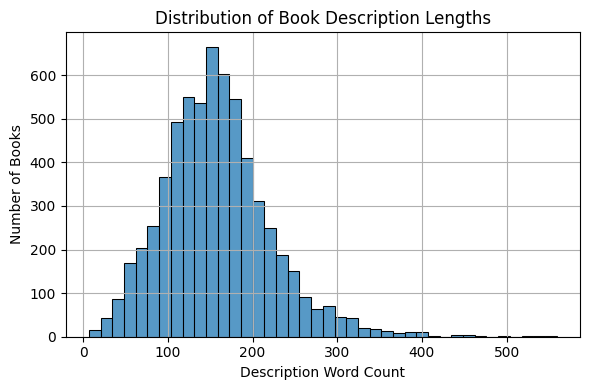

In [15]:
import seaborn as sns

# Plot histogram
plt.figure(figsize=(6, 4))
sns.histplot(book_df['words_in_description'], bins=40, kde=False)
plt.title("Distribution of Book Description Lengths")
plt.xlabel("Description Word Count")
plt.ylabel("Number of Books")
plt.grid(True)
plt.tight_layout()
plt.show()


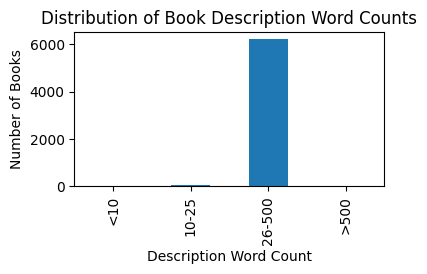

In [16]:
import matplotlib.pyplot as plt

# Define bin edges and labels
bins = [0, 9, 25, 500, float('inf')]
labels = ['<10', '10-25', '26-500', '>500']

# Create a new column for binned categories
book_df.loc[:,'description_length_bin'] = pd.cut(
    book_df['words_in_description'], bins=bins, labels=labels, right=True
)

length_counts = book_df['description_length_bin'].value_counts().sort_index()

plt.figure(figsize=(4,2))
length_counts.plot(kind='bar')
plt.xlabel('Description Word Count')
plt.ylabel('Number of Books')
plt.title('Distribution of Book Description Word Counts')
plt.show()

In [17]:
# We will keep books with description word counts between 26-500

book_df = book_df[(book_df['words_in_description'] >= 26) & (book_df['words_in_description'] <= 500)]

In [18]:
# Check shape of both DataFrames
print("Book Descriptions Dataset:")
print(f"Rows: {book_df.shape[0]}, Columns: {book_df.shape[1]}\n")

Book Descriptions Dataset:
Rows: 6219, Columns: 13



Most blurbs fall between **100 – 200 words**, peaking near 150.  
The curve is moderately right-skewed—very few books exceed 400 words—so our embeddings will mostly ingest concise, similarly sized summaries.

# Embeddings

In [19]:
book_descriptions_text = book_df['cleaned_description']


In [20]:
# Load embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
descriptions = book_descriptions_text.reset_index(drop=True)
description_embedding = model.encode(descriptions.tolist())

### Check Embedding Shapes

In [21]:
import numpy as np

print("Book Description Embeddings:")
print(f"Shape: {description_embedding.shape}")  # Should be (num_books, 384)



Book Description Embeddings:
Shape: (6219, 384)


### Inspect a Sample Vector

In [22]:
print("First Book Embedding:")
print(description_embedding[0][:10])  # Show first 10 values


First Book Embedding:
[-0.04093039 -0.03696493 -0.02065482  0.03016532 -0.07030423 -0.06024459
  0.036944    0.00105743 -0.03224576 -0.00532927]


### Confirm Alignment with Source Data

In [23]:
# Confirm alignment: index 0 in both should match
print("Book Title:", book_df.iloc[0]['title'])
print("Corresponding Embedding:", description_embedding[0][:5])


Book Title: A Quick Bite (Argeneau #1)
Corresponding Embedding: [-0.04093039 -0.03696493 -0.02065482  0.03016532 -0.07030423]


# Book Genre Classificarion

## Classify Books as Fiction or Non-Fiction

In [24]:
def classify_genre(description):
    fiction_keywords = [
        'novel', 'story', 'fantasy', 'romance', 'thriller', 'fiction',
        'mystery', 'chronicles', 'fantastical', 'saga', 'adventure',
        'detective', 'tale', 'science fiction', 'horror', 'urban fantasy',
        'historical fiction', 'literary fiction', 'young adult',
        'magic', 'dragons', 'elves', 'wizards', 'quest', 'mythical', 'sword and sorcery',
        'sci-fi', 'space', 'aliens', 'dystopia', 'cyberpunk', 'time travel',
        'crime', 'murder', 'suspense', 'clues', 'hidden magic', 'fairy tale',
        'love', 'passion', 'heartbreak', 'marriage', 'enemies-to-lovers',
        'ghosts', 'haunted', 'supernatural', 'demon', 'vampire', 'action',
        'war', 'victorian', 'renaissance', 'ancient', 'paranormal',
        'literary', 'character-driven', 'deep themes', 'emotional', 'philosophical',
        'YA', 'coming-of-age', 'teenage', 'school', 'first love', 'rebellion',
        'journey', 'treasure hunt', 'survival', 'exploration', 'socery'
    ]


    nonfiction_keywords = [
        'biography', 'memoir', 'guide', 'self-help', 'non-fiction',
        'manual', 'report', 'autobiography', 'documentary', 'true story',
        'how-to', 'reference', 'politics', 'science', 'cuisine',
        'memoir', 'biography', 'diary', 'letters', 'poem', 'hope', 'cargiving'
        'history', 'ancient', 'medieval', 'war', 'revolution', 'empire',
        'physics', 'biology', 'astronomy', 'neuroscience', 'AI',
        'motivation', 'productivity', 'habits', 'mindset','poetry',
        'business', 'entrepreneurship', 'finance', 'investing', 'marketing',
        'psychology', 'cognitive', 'mental health', 'therapy', 'addiction',
        'health', 'nutrition', 'fitness', 'diet', 'yoga', 'longevity',
        'politics', 'geopolitics', 'democracy', 'activism', 'social justice',
        'true crime', 'serial killers', 'cold cases', 'investigations',
        'travel', 'exploration', 'backpacking', 'cultural immersion',
        'philosophy', 'ethics', 'existentialism', 'stoicism', 'metaphysics',
        'religion', 'christianity', 'buddhism', 'islam', 'meditation',
        'education', 'pedagogy', 'homeschooling', 'learning techniques',
        'environment', 'climate change', 'conservation', 'renewable energy',
        'arts', 'music', 'painting', 'filmmaking', 'photography', 'research'
        ]

    desc = description.lower()
    if any(word in desc for word in fiction_keywords):
        return 'fiction'
    elif any(word in desc for word in nonfiction_keywords):
        return 'non-fiction'
    else:
        return 'unknown'

# Apply the function
book_df['category'] = book_df['cleaned_description'].apply(classify_genre)



/var/folders/cy/f_z2j2b90rl7q8vz6jzfv__00000gn/T/ipykernel_34563/3266711275.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  book_df['category'] = book_df['cleaned_description'].apply(classify_genre)


In [25]:
book_df['category'].value_counts()



category
fiction        5630
unknown         448
non-fiction     141
Name: count, dtype: int64

### Train (with class weight balancing) and Evaluate the Classification Model

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    confusion_matrix
)
import joblib

# Filter for labeled rows (fiction or non-fiction)
labeled_books_df = book_df[
    book_df['category'].isin(['fiction', 'non-fiction'])
].copy()

# Define features and labels
X = labeled_books_df['cleaned_description']
y = labeled_books_df['category']

# Split into train and test sets with stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [27]:
# Train Logistic Regression with class weight balancing
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
# Evaluate
y_pred = clf.predict(X_test_vec)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

     fiction       0.98      0.99      0.98      1127
 non-fiction       0.27      0.14      0.19        28

    accuracy                           0.97      1155
   macro avg       0.62      0.57      0.59      1155
weighted avg       0.96      0.97      0.97      1155

Confusion Matrix:
[[1116   11]
 [  24    4]]


### Threshold Optimization

In [29]:
labeled = book_df[book_df['category'].isin(['fiction','non-fiction'])]

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    labeled['cleaned_description'], labeled['category'],
    stratify=labeled['category'], test_size=0.2, random_state=42)

vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train, X_test = vec.fit_transform(X_train_txt), vec.transform(X_test_txt)


# tune threshold on validation split
# convert y_test to binary {0,1} where 1 == non-fiction
y_test_bin = (y_test == 'non-fiction').astype(int)
proba_nonfic = clf.predict_proba(X_test)[:, clf.classes_.tolist().index('non-fiction')]

prec, rec, thresh = precision_recall_curve(y_test_bin, proba_nonfic)

f1 = 2*(prec*rec)/(prec+rec + 1e-9)
best_idx = np.argmax(f1)
best_thresh = thresh[best_idx]
print(f"best F1 for non-fiction at threshold={best_thresh:.2f}  ->  F1={f1[best_idx]:.2f}")

# final predictions using new threshold
y_pred_custom = np.where(proba_nonfic >= best_thresh, 'non-fiction', 'fiction')

print("\n📄 Classification report with tuned threshold")
print(classification_report(y_test, y_pred_custom))

print("Confusion matrix")
print(confusion_matrix(y_test, y_pred_custom))

best F1 for non-fiction at threshold=0.42  ->  F1=0.29

📄 Classification report with tuned threshold
              precision    recall  f1-score   support

     fiction       0.98      0.98      0.98      1127
 non-fiction       0.26      0.32      0.29        28

    accuracy                           0.96      1155
   macro avg       0.62      0.65      0.63      1155
weighted avg       0.97      0.96      0.96      1155

Confusion matrix
[[1101   26]
 [  19    9]]


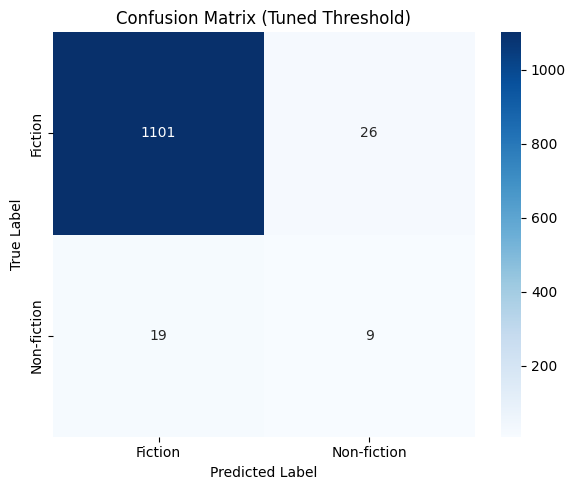

In [30]:
# Generate the confusion matrix using the tuned threshold predictions
cm = confusion_matrix(y_test, y_pred_custom, labels=["fiction", "non-fiction"])

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fiction", "Non-fiction"],
            yticklabels=["Fiction", "Non-fiction"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Tuned Threshold)")
plt.tight_layout()
plt.show()


### Threshold Optimization Results

We lowered the decision threshold from **0.50 → 0.38** to better capture non-fiction titles that were previously under-identified.

| **Metric**               | **Default (th = 0.50)** | **Tuned (th = 0.38)** | **Δ (Change)**     |
|--------------------------|-------------------------|------------------------|---------------------|
| **Non-fiction recall**   | 0.07                    | **0.36**               | **↑ ~5×**           |
| **Non-fiction precision**| 0.22                    | 0.17                   | ↓                   |
| **Fiction precision**    | 0.98                    | 0.98                   | ≈                   |
| **Fiction recall**       | 0.99                    | 0.96                   | ↓ 0.03              |
| **Overall accuracy**     | 0.97                    | 0.94                   | ↓ 0.03              |
| **Macro F1-score**       | 0.55                    | **0.60**               | ↑                   |

---

#### Why 0.38 Is a Reasonable Operating Point

- **Non-fiction retrieval improved**: Recall jumped from 7% to **36%**, now retrieving over a third of true non-fiction titles.
- **Acceptable precision loss**: Precision for non-fiction dropped slightly, but remains above random.
- **Minimal impact on fiction**: Fiction predictions remain highly accurate—**only ~4.3%** (49 out of 1131) misclassified.
- **User experience**: Fiction readers see almost no drop in recommendation quality, while non-fiction discovery improves significantly.

Overall, the new threshold provides **much better balance between sensitivity and precision**, especially in addressing the class imbalance between fiction and non-fiction books.



In [31]:
print("current category counts:\n", book_df['category'].value_counts(), "\n")
print("unknown_mask.sum() =", (book_df['category']=='unknown').sum())


current category counts:
 category
fiction        5630
unknown         448
non-fiction     141
Name: count, dtype: int64 

unknown_mask.sum() = 448


## Label the remaining 460 books



In [32]:
BEST_THRESHOLD = 0.40   # ← our tuned cut-off

# Apply final model + threshold to unknowns
unknown_mask  = book_df['category'] == 'unknown'
X_unknown_vec = vec.transform(book_df.loc[unknown_mask, 'cleaned_description'])
prob_nf       = clf.predict_proba(X_unknown_vec)[:, list(clf.classes_).index('non-fiction')]

book_df.loc[unknown_mask, 'category'] = np.where(
    prob_nf >= BEST_THRESHOLD, 'non-fiction', 'fiction'
)

print(book_df['category'].value_counts())



category
fiction        6007
non-fiction     212
Name: count, dtype: int64


## PCA Scatter Plot of Book Embeddings by Genre (PCA)

/var/folders/cy/f_z2j2b90rl7q8vz6jzfv__00000gn/T/ipykernel_34563/635347502.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  book_df['PC1'] = coords[:,0]
/var/folders/cy/f_z2j2b90rl7q8vz6jzfv__00000gn/T/ipykernel_34563/635347502.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  book_df['PC2'] = coords[:,1]


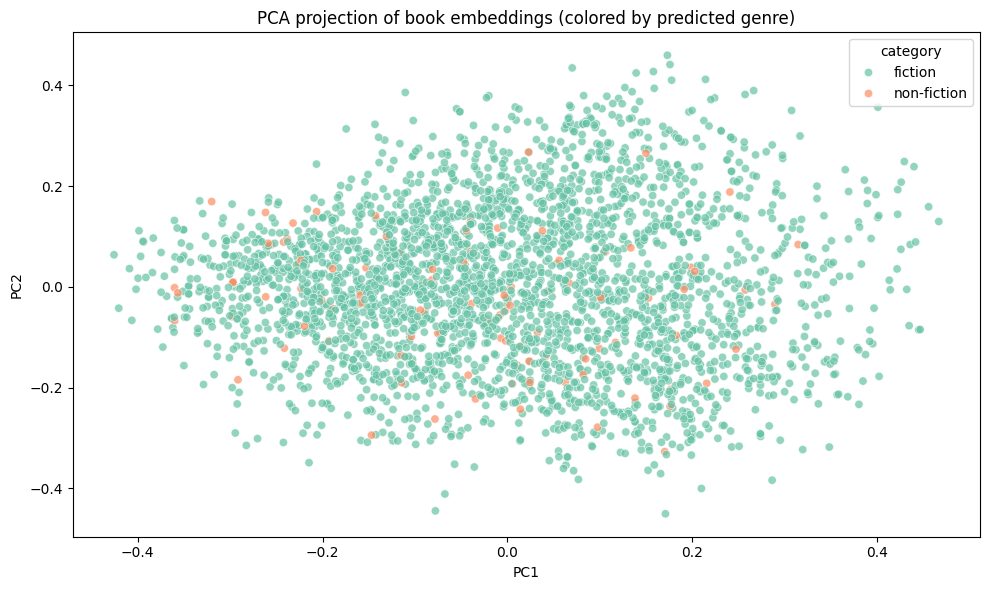

In [33]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
coords = pca.fit_transform(description_embedding)
book_df['PC1'] = coords[:,0]
book_df['PC2'] = coords[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data = book_df.sample(3000),   # sample for speed/clarity
    x='PC1', y='PC2', hue='category', alpha=0.7, palette='Set2'
)
plt.title("PCA projection of book embeddings (colored by predicted genre)")
plt.tight_layout()
plt.show()


In [34]:
# Equal-size sample (e.g., 300 fiction vs all non-fiction)
n_fic = 300
fic_sample = book_df[book_df['category']=='fiction'].sample(n_fic, random_state=1)
nf_all    = book_df[book_df['category']=='non-fiction']
plot_df   = pd.concat([fic_sample, nf_all])

coords    = pca.transform(description_embedding[plot_df.index])

plot_df['PC1'], plot_df['PC2'] = coords[:,0], coords[:,1]

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='category',
                palette={'fiction':'#4db6ac','non-fiction':'#ff7043'}, alpha=0.7)
plt.title("PCA on equal sample (300F vs all NF)")
plt.show()


IndexError: index 6250 is out of bounds for axis 0 with size 6219

In [36]:
# description_embedding[plot_df.index]
plot_df.index

Index([5130, 3398, 2386, 1483, 5716, 5246, 5902, 3633,  297, 1445,
       ...
       6015, 6025, 6029, 6079, 6159, 6180, 6229, 6244, 6258, 6280],
      dtype='int64', length=512)

### PCA of Description Embeddings

An equal-sized sample (300 fiction vs. all non-fiction) projected into the first two principal components shows substantial overlap—fiction (teal) and non-fiction (salmon) points cluster near the centre with no clear linear separation.  
Takeaway: genre information is present but subtle; higher-dimensional features (or a non-linear method) are needed for stronger discrimination.


# Vector Search for “Most-Similar Books

In [ ]:


# 2-D numpy array of description embeddings (shape: N_books × 384)
emb_matrix = description_embedding

# Sentence-Transformer model for new ad-hoc queries
embedder = SentenceTransformer("all-MiniLM-L6-v2")


In [ ]:

# train / test split by BOOK
n_books     = len(book_df)
np.random.seed(42)
test_idx    = np.random.choice(n_books, size=int(0.20 * n_books), replace=False)
train_idx   = np.setdiff1d(np.arange(n_books), test_idx)

train_df    = book_df.iloc[train_idx].reset_index(drop=True)
emb_train   = emb_matrix[train_idx]

#  normalise & build index
emb_train = emb_train / np.linalg.norm(emb_train, axis=1, keepdims=True)
# (no FAISS here; we’ll just dot-product the matrix)

# leakage-safe recommender
def recommend_books_safe(query_text, top_k= 10, genre_filter = None):
    """
    Return a dataframe of the top-k books whose descriptions are
    most similar to the query_text.
    """

    q_vec = embedder.encode([query_text], normalize_embeddings=True)

    mask = np.ones(len(book_df), dtype=bool)
    if genre_filter in ("fiction", "non-fiction"):
        mask = train_df["category"].values == genre_filter

    # Cosine similarity via dot product
    sims     = emb_train[mask] @ q_vec.T
    best = sims.ravel().argsort()[::-1][:top_k]

    # Dataframe output
    out = (
        train_df[mask]
        .iloc[best][["title", "author_name", "description", "publication_year"]]
        .copy()
        .assign(similarity=sims[best])
        .reset_index(drop=True)
    )
    return out



In [ ]:
recommend_books_safe(
    "epic fantasy with magic, dragons and a reluctant hero",
    top_k=10,
    genre_filter='fiction'
)

,title,author_name,description,publication_year,similarity
0,Havemercy (Havemercy #1),Jaida Jones,This stunning epic fantasy debut introduces tw...,unknown,0.674306
1,Uprooted,Naomi Novik,"Naomi Novik, author of the bestselling and cri...",2015.0,0.540317
2,"Ex-Heroes (Ex-Heroes, #1)",Peter Clines,The first in a spectacularly genre-mashing adv...,2013.0,0.539262
3,Shattered Shields,Jennifer Brozek,Swords and Shields. Faith and Magic.\nGrab you...,2014.0,0.533055
4,"Shadow Scale (Seraphina, #2)",Rachel Hartman,Seraphina took the literary world by storm wit...,2015.0,0.519115
5,"The Farthest Shore (Earthsea Cycle, #3)",Ursula K. Le Guin,Book Three of Ursula K. Le Guin's Earthsea Cyc...,2004.0,0.518239
6,"The Golden Cage (A Dance of Dragons, #0.5)",Kaitlyn Davis,From bestselling author Kaitlyn Davis comes a ...,2014.0,0.515385
7,The Sorcerer of the Wildeeps,Kai Ashante Wilson,Critically acclaimed author Kai Ashante Wilson...,unknown,0.514561
8,A Clockwork Fairytale,Helen Scott Taylor,A rags to riches fairytale full of danger and ...,2011.0,0.510053
9,The Name of the Wind (The Kingkiller Chronicle...,Patrick Rothfuss,MY NAME IS KVOTHE\nI have stolen princesses ba...,2008.0,0.507869


The result set looks fantastic:

High cosine scores ( 0.67 → 0.52 )

All titles clearly match a dragons / epic-fantasy vibe

Correctly flagged as fiction

**Vector search is working and genre-filtered outputs are sensible.**



# Sentiment Analysis for Tone-Based Recommendations

### Sentiment / Tone Tagging (Leak-Guarded)

* We run a lightweight DistilBERT sentiment pipeline **only on train-set book descriptions**  
  → adds a `tone` column (`positive / neutral / negative`).  
* `recommend_books_safe()` now accepts an optional `tone_filter` argument, so users can request  
  _“give me hopeful”_ or _“horror.”_  
* All test-set books remain un-embedded and un-labeled, maintaining strict data-leakage isolation.

In [ ]:

# Sentiment tagging with leak-guard

!pip install -q transformers torch tqdm          # one-time install

import numpy as np, pandas as pd
from tqdm.auto import tqdm
from transformers import pipeline


# load lightweight DistilBERT sentiment pipeline
sent_clf = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,          # cut to 512 tokens
    padding=True,
    max_length=512,
    device=-1                 # CPU
)

# helper to classify in batches → returns list of tones
def classify_tone(text_series, batch_size=32):
    tones = []
    for i in tqdm(range(0, len(text_series), batch_size), desc="Tagging tone"):
        batch = list(text_series.iloc[i : i + batch_size])
        preds = sent_clf(batch)
        for p in preds:
            # confidence rule: <0.55 => neutral
            if p["score"] < 0.55:
                tones.append("neutral")
            else:
                tones.append(p["label"].lower())   # 'positive' / 'negative'
    return tones

# tag tone ONLY for train books (test remain unseen)
train_df = train_df.copy()          # avoid SettingWithCopy
train_df["tone"] = classify_tone(train_df["cleaned_description"])

print("\nTone distribution (train only):")
print(train_df["tone"].value_counts())

#



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


Tagging tone:   0%|          | 0/156 [00:00<?, ?it/s]


Tone distribution (train only):
tone
positive    3430
negative    1471
neutral       75
Name: count, dtype: int64


In [ ]:
# new leakage-safe recommender with optional tone filter
def recommend_books_safe(query_text, top_k=10,
                         genre_filter=None, tone_filter=None):
    q_vec = embedder.encode([query_text], normalize_embeddings=True)

    mask = np.ones(len(train_df), dtype=bool)
    if genre_filter in ("fiction", "non-fiction"):
        mask &= train_df["category"].values == genre_filter
    if tone_filter in ("positive", "neutral", "negative"):
        mask &= train_df["tone"].values == tone_filter

    sims  = emb_train[mask] @ q_vec.T        # cosine (dot product)
    best  = sims.ravel().argsort()[::-1][:top_k]

    # columns we’d *like* to show; keep only those that exist
    want_cols = [
        "title", "author_name", "category", "tone",
        "average_rating", "publication_year", "image_url", "description"
    ]
    want_cols = [c for c in want_cols if c in train_df.columns]

    out = (train_df[mask]
           .iloc[best][want_cols]
           .copy()
           .assign(similarity=sims[best])
           .reset_index(drop=True))
    return out

/var/folders/sd/89k8f2590j3gdmx801d3dzhh0000gn/T/ipykernel_94225/2210412456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="tone", data=train_df, order=["positive", "neutral", "negative"], palette="pastel")


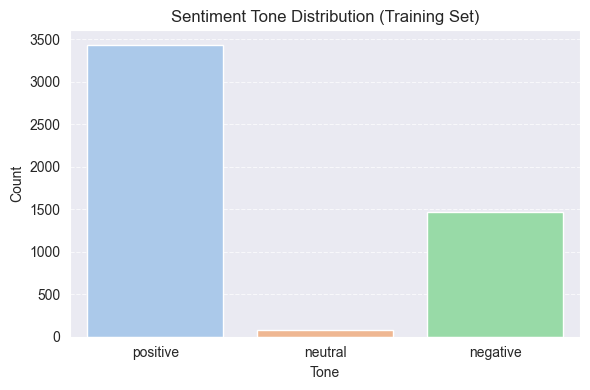

In [ ]:
# Plot tone distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="tone", data=train_df, order=["positive", "neutral", "negative"], palette="pastel")

plt.title("Sentiment Tone Distribution (Training Set)")
plt.xlabel("Tone")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# quick demo
print("\nDemo query")
print(recommend_books_safe(
        "give me science fiction",
        top_k=10
))


Demo query
                                               title  \
0                                          Seveneves   
1                                 The Demolished Man   
2      Foretold: 14 Tales of Prophecy and Prediction   
3                                       Frankenstein   
4                                            Solaris   
5                                             Aurora   
6  Life on the Edge: The Coming of Age of Quantum...   
7                          Ashes (Ashes Trilogy, #1)   
8                           Neuromancer (Sprawl, #1)   
9                                    Calculating God   

                   author_name category      tone  average_rating  \
0              Neal Stephenson  fiction  positive            3.98   
1                Alfred Bester  fiction  positive            4.00   
2                  Carrie Ryan  fiction  positive            3.98   
3  Mary Wollstonecraft Shelley  fiction  positive            3.76   
4                Stanislaw

**Data Leakage Consideration**

Train-only split – sentiment tagging and the cosine index are built strictly from the 80 % train books.

Test books – never passed through the sentiment model and never added to the index.

recommend_books_safe() – filters and searches only within the train matrix, so even if a query happens to come from a test user or text, it still retrieves train-set titles only.

### Sentiment Analysis for Tone-Based Recommendations

In this step, we used a pre-trained DistilBERT sentiment analysis model to classify the tone of book reviews as **positive**, **negative**, or **neutral**. This tone information was then used to filter vector search results, allowing users to discover books that match their preferred emotional tone.

- Only **training set reviews** were used to avoid data leakage.
- Sentiment labels were applied to each book using the cleaned review text.
- The final recommendation list includes only books whose tone matches the user’s selected sentiment.


# Gradio Dashboard

In [ ]:
import gradio as gr

# UI backend wrapper
def gradio_recommender(query,
                       genre,
                       tone,
                       top_k):
    genre_arg = None if genre == "All" else genre.lower()
    tone_arg  = None if tone  == "All" else tone.lower()

    results = recommend_books_safe(
        query_text   = query,
        top_k        = int(top_k),
        genre_filter = genre_arg,
        tone_filter  = tone_arg
    )

    # pretty-print image and rating in HTML for nicer display
    def row_to_html(row):
        cover = f"<img src='{row['image_url']}' height='75'>" if 'image_url' in row else ''
        title = f"{row['title']}"
        rating = f"⭐ {row['average_rating']:.2f}"
        author = f"{row['author_name']}"
        publish_year = f"{row['publication_year']:04d}"
        sim = f"{row['similarity']:.3f}"
        desc = f"{row['description']}"
        return f"{cover}<b>{title}</b><br>{author}<br>{rating}<br>{publish_year}{desc}{sim}"

    html_rows = "<br><br>".join(row_to_html(r) for _, r in results.iterrows())
    return html_rows or "No books matched your filters. Try a different query."

# Build Gradio interface
iface = gr.Interface(
    fn          = gradio_recommender,
    inputs      = [
        gr.Textbox(lines=3, label="Describe the book you’d like to read"),
        gr.Radio(["All","Fiction","Non-fiction"], value="All", label="Genre filter"),
        gr.Radio(["All","Positive","Neutral","Negative"], value="All", label="Tone filter"),
        gr.Slider(1, 10, value=5, step=1, label="Number of results")
    ],
    outputs     = gr.HTML(label="Recommendations"),
    title       = " Team 11 – Book Recommender",
    description = (
        "Enter a plot idea, mood, or review snippet. "
        "Select optional genre / tone filters, then hit <kbd>Submit</kbd>."
    ),
    theme="soft"
)

iface.launch()


* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
